# EyePole: 2-D constrained eye-dipole simulation and estimation

This notebook demonstrates a simple version of the EyePole idea for the common case where only **left, right, up, and down EOG electrodes** are available.

The important modeling decision is that we do **not** ask two bipolar EOG channels to estimate an unconstrained three-dimensional dipole. Instead, the estimator tracks only

\[
\mathbf x_t = [p_x(t),\;p_y(t)]^T.
\]

We assume the corneo-retinal dipole has approximately constant magnitude \(p_0\), and that the forward-facing component is positive. Therefore

\[
p_z(t) = +\sqrt{p_0^2 - p_x(t)^2 - p_y(t)^2}.
\]

This gives a full three-dimensional dipole for the physics model while leaving only two unknown state variables.

The notebook covers:

1. a generative model of gaze, saccades, fixation drift, and the 3-D eye dipole;
2. four-electrode EOG simulation using the finite two-pole near-field model;
3. constrained 2-D estimation using both the near-field and far-field forward models;
4. conversion from estimated dipole to gaze direction using both the exact simulator geometry and a calibration-style transfer function.

The code is intentionally written for readability rather than maximum speed.

## Coordinate system and geometry

We use a simple eye-centered Cartesian coordinate system:

- **+x**: right
- **+y**: up
- **+z**: forward

The eye center is the origin. The EOG electrodes sit outside the eye around the orbital rim. Only `R`, `L`, `U`, and `D` are used.

The finite near-field model represents the eye dipole as two poles separated by a configurable distance \(s\). For dipole moment \(\mathbf p\),

\[
\mathbf r_+ = \frac{s}{2}\frac{\mathbf p}{\|\mathbf p\|},\qquad
\mathbf r_- = -\frac{s}{2}\frac{\mathbf p}{\|\mathbf p\|},
\]

and electrode \(i\) sees a voltage proportional to

\[
\frac{\|\mathbf p\|}{s}
\left(
\frac{1}{\|\mathbf r_i-\mathbf r_+\|}
-
\frac{1}{\|\mathbf r_i-\mathbf r_-\|}
\right).
\]

The far-field model replaces this finite source/sink pair by the usual point-dipole approximation. We will generate data from the **near-field** model, then estimate it using both models.

In [1]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

# The notebook is bundled with the EyePole source tree. Add that directory to
# Python's path so the example runs without requiring a package installation.
package_root = Path.cwd()
if (package_root / "eyepole").exists():
    sys.path.insert(0, str(package_root))
elif Path("/mnt/data/eyepole_simple").exists():
    sys.path.insert(0, "/mnt/data/eyepole_simple")

from eyepole import EyePole

rng = np.random.default_rng(7)

In [2]:
# Four physical electrodes, specified in millimeters relative to the eye center.
# The modest positive z coordinate simply places them slightly anterior to the
# eye center rather than in a perfectly flat x-y plane.
electrode_positions_mm = {
    "R": [32.0, 0.0, 10.0],
    "L": [-32.0, 0.0, 10.0],
    "U": [0.0, 28.0, 10.0],
    "D": [0.0, -28.0, 10.0],
}

# Two bipolar EOG channels are formed from the four electrodes.
channels = [
    ("R", "L"),
    ("U", "D"),
]

# The finite dipole consists of two poles this far apart. This parameter is
# deliberately exposed because one goal of EyePole is to let us test how the
# assumed near-field geometry changes the inferred dipole.
pole_separation_mm = 20.0

# The absolute scale of the dipole is arbitrary in this demonstration. The gain
# below converts the physics model to EOG voltages on the order of hundreds of
# microvolts over normal gaze angles.
dipole_magnitude = 1.0
forward_gain = 1e-6

near_model = EyePole(
    electrode_positions_mm=electrode_positions_mm,
    channels=channels,
    pole_separation_mm=pole_separation_mm,
    field_model="near",
    gain=forward_gain,
)

far_model = EyePole(
    electrode_positions_mm=electrode_positions_mm,
    channels=channels,
    field_model="far",
    gain=forward_gain,
)

print("Recorded channels:", near_model.channel_names)
print("Far-field observation matrix C shape:", far_model.C.shape)
print("Far-field rank with only R-L and U-D channels:", np.linalg.matrix_rank(far_model.C))

Recorded channels: ('R-L', 'U-D')
Far-field observation matrix C shape: (2, 3)
Far-field rank with only R-L and U-D channels: 2


The far-field observation matrix has only two rows because only two independent bipolar channels are recorded. Its rank therefore cannot exceed two. This is why an unconstrained 3-D inverse problem is underdetermined.

The constant-magnitude, forward-facing constraint changes the problem. We estimate \((p_x,p_y)\), then reconstruct the physically allowed positive \(p_z\).

In [3]:
def gaze_angles_to_dipole(horizontal_deg, vertical_deg, magnitude=1.0):
    """Convert horizontal/vertical gaze angles into a 3-D dipole vector.

    Parameters
    ----------
    horizontal_deg : float or numpy.ndarray
        Horizontal gaze angle in degrees. Positive values look to the right.
    vertical_deg : float or numpy.ndarray
        Vertical gaze angle in degrees. Positive values look upward.
    magnitude : float, default=1.0
        Constant magnitude of the corneo-retinal dipole.

    Returns
    -------
    dipole : numpy.ndarray, shape (..., 3)
        Eye dipole vector(s) in the x-right, y-up, z-forward coordinate system.

    Notes
    -----
    This simulator assumes that the dipole axis rotates with the eye. The +z
    component therefore stays positive for the normal forward field of view.
    """
    horizontal = np.deg2rad(np.asarray(horizontal_deg, dtype=float))
    vertical = np.deg2rad(np.asarray(vertical_deg, dtype=float))

    p_x = np.sin(horizontal) * np.cos(vertical)
    p_y = np.sin(vertical)
    p_z = np.cos(horizontal) * np.cos(vertical)

    direction = np.stack([p_x, p_y, p_z], axis=-1)
    return float(magnitude) * direction


def dipole_to_gaze_angles(dipole):
    """Invert the simulator geometry and return horizontal/vertical gaze angle.

    Parameters
    ----------
    dipole : numpy.ndarray, shape (..., 3)
        Three-dimensional eye dipole vector(s), with +z pointing forward.

    Returns
    -------
    angles_deg : numpy.ndarray, shape (..., 2)
        Columns are horizontal and vertical gaze angle in degrees.
    """
    p = np.asarray(dipole, dtype=float)
    direction = p / np.linalg.norm(p, axis=-1, keepdims=True)

    horizontal = np.arctan2(direction[..., 0], direction[..., 2])
    vertical = np.arctan2(
        direction[..., 1],
        np.sqrt(direction[..., 0] ** 2 + direction[..., 2] ** 2),
    )

    return np.rad2deg(np.stack([horizontal, vertical], axis=-1))

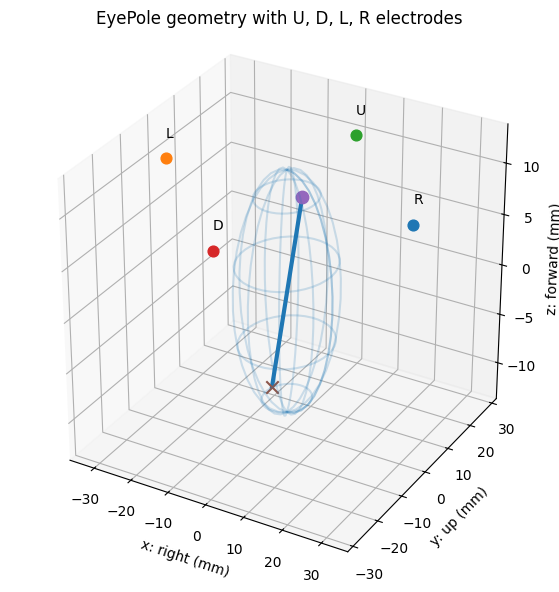

In [4]:
# Plot the physical geometry for one example gaze direction.
example_horizontal_deg = 18.0
example_vertical_deg = 8.0
example_dipole = gaze_angles_to_dipole(
    example_horizontal_deg,
    example_vertical_deg,
    magnitude=dipole_magnitude,
)

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

# Draw a simple eyeball sphere for orientation. This is only a visual reference;
# the forward model itself uses the electrode positions and the two dipole poles.
u = np.linspace(0, 2 * np.pi, 40)
v = np.linspace(0, np.pi, 20)
eye_radius_mm = 12.0
x_eye = eye_radius_mm * np.outer(np.cos(u), np.sin(v))
y_eye = eye_radius_mm * np.outer(np.sin(u), np.sin(v))
z_eye = eye_radius_mm * np.outer(np.ones_like(u), np.cos(v))
ax.plot_wireframe(x_eye, y_eye, z_eye, rstride=4, cstride=4, alpha=0.2)

for name, position in electrode_positions_mm.items():
    position = np.asarray(position)
    ax.scatter(position[0], position[1], position[2], s=60)
    ax.text(position[0], position[1], position[2] + 2, name)

# Convert the dipole direction into the locations of the two finite poles.
direction = example_dipole / np.linalg.norm(example_dipole)
half_separation = 0.5 * pole_separation_mm
positive_pole_mm = half_separation * direction
negative_pole_mm = -half_separation * direction

ax.scatter(*positive_pole_mm, s=80, marker="o")
ax.scatter(*negative_pole_mm, s=80, marker="x")
ax.plot(
    [negative_pole_mm[0], positive_pole_mm[0]],
    [negative_pole_mm[1], positive_pole_mm[1]],
    [negative_pole_mm[2], positive_pole_mm[2]],
    linewidth=3,
)

ax.set_xlabel("x: right (mm)")
ax.set_ylabel("y: up (mm)")
ax.set_zlabel("z: forward (mm)")
ax.set_title("EyePole geometry with U, D, L, R electrodes")
ax.set_box_aspect((1, 1, 1))
plt.show()

## Generative eye movements

The next function builds a simple but useful eye-movement sequence:

- periods of fixation;
- rapid saccades between fixation targets;
- small stochastic fixation drift;
- a tiny high-frequency tremor term.

Saccades use a minimum-jerk interpolation so they do not look like instantaneous steps. This is still a deliberately simple generative model; the goal is to test EyePole mechanics, not to reproduce every oculomotor subsystem.

In [5]:
def minimum_jerk_progress(n_samples):
    """Return a smooth 0-to-1 trajectory with zero endpoint velocity.

    This is a convenient way to create a visually plausible saccade without
    introducing a more detailed ocular motor model.
    """
    tau = np.linspace(0.0, 1.0, int(n_samples), endpoint=False)
    return 10 * tau**3 - 15 * tau**4 + 6 * tau**5


def simulate_gaze_sequence(fs=250.0, random_state=0):
    """Generate fixations, saccades, fixation drift, and ocular tremor.

    Parameters
    ----------
    fs : float, default=250.0
        Sampling rate in samples per second.
    random_state : int, default=0
        Seed controlling the small stochastic fixation drift.

    Returns
    -------
    time : numpy.ndarray, shape (n_samples,)
        Time in seconds.
    horizontal_deg : numpy.ndarray, shape (n_samples,)
        Horizontal gaze angle; positive is rightward.
    vertical_deg : numpy.ndarray, shape (n_samples,)
        Vertical gaze angle; positive is upward.
    """
    local_rng = np.random.default_rng(random_state)

    # A small sequence of gaze targets chosen to exercise horizontal, vertical,
    # and diagonal eye movements while staying in a normal central field.
    targets_deg = [
        (0.0, 0.0),
        (15.0, 0.0),
        (-12.0, 8.0),
        (20.0, -10.0),
        (-18.0, -6.0),
        (0.0, 12.0),
        (10.0, 5.0),
        (0.0, 0.0),
    ]
    fixation_duration_s = [0.70, 0.65, 0.75, 0.60, 0.70, 0.65, 0.60, 0.80]

    horizontal = []
    vertical = []
    current_target = np.asarray(targets_deg[0], dtype=float)

    for target_index, fixation_duration in enumerate(fixation_duration_s):
        n_fixation = max(1, int(round(fixation_duration * fs)))
        horizontal.extend([current_target[0]] * n_fixation)
        vertical.extend([current_target[1]] * n_fixation)

        if target_index == len(targets_deg) - 1:
            break

        next_target = np.asarray(targets_deg[target_index + 1], dtype=float)
        amplitude_deg = np.linalg.norm(next_target - current_target)

        # Larger saccades take slightly longer. The exact relationship is not
        # intended as a physiological fit; it simply prevents every movement
        # from having the same duration.
        saccade_duration_s = np.clip(
            0.025 + 0.0012 * amplitude_deg,
            0.025,
            0.070,
        )
        n_saccade = max(3, int(round(saccade_duration_s * fs)))
        progress = minimum_jerk_progress(n_saccade)
        path = (
            current_target[None, :]
            + progress[:, None] * (next_target - current_target)[None, :]
        )

        horizontal.extend(path[:, 0])
        vertical.extend(path[:, 1])
        current_target = next_target

    horizontal = np.asarray(horizontal)
    vertical = np.asarray(vertical)
    time = np.arange(len(horizontal)) / fs

    # Fixation drift is modeled as a very small, strongly correlated random
    # walk. The eye therefore wanders slightly instead of remaining perfectly
    # fixed at every target.
    horizontal_drift = np.zeros_like(horizontal)
    vertical_drift = np.zeros_like(vertical)
    for k in range(1, len(horizontal)):
        horizontal_drift[k] = (
            0.995 * horizontal_drift[k - 1]
            + local_rng.normal(scale=0.004)
        )
        vertical_drift[k] = (
            0.995 * vertical_drift[k - 1]
            + local_rng.normal(scale=0.004)
        )

    # A tiny tremor term is added only to keep the simulated fixation from being
    # mathematically flat. Its amplitude is intentionally small.
    horizontal_tremor = 0.02 * np.sin(2 * np.pi * 30.0 * time)
    vertical_tremor = 0.02 * np.sin(2 * np.pi * 27.0 * time + 0.8)

    horizontal = horizontal + horizontal_drift + horizontal_tremor
    vertical = vertical + vertical_drift + vertical_tremor

    return time, horizontal, vertical

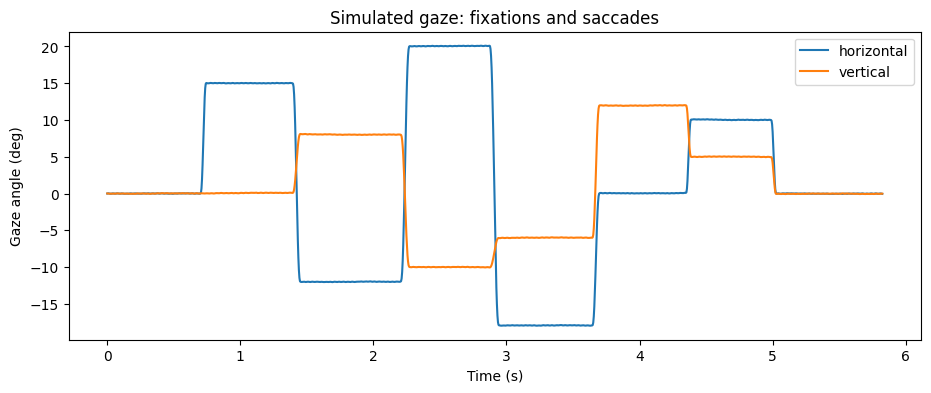

In [6]:
fs = 250.0
time, horizontal_true_deg, vertical_true_deg = simulate_gaze_sequence(
    fs=fs,
    random_state=3,
)

true_dipole = gaze_angles_to_dipole(
    horizontal_true_deg,
    vertical_true_deg,
    magnitude=dipole_magnitude,
)

plt.figure(figsize=(11, 4))
plt.plot(time, horizontal_true_deg, label="horizontal")
plt.plot(time, vertical_true_deg, label="vertical")
plt.xlabel("Time (s)")
plt.ylabel("Gaze angle (deg)")
plt.title("Simulated gaze: fixations and saccades")
plt.legend()
plt.show()

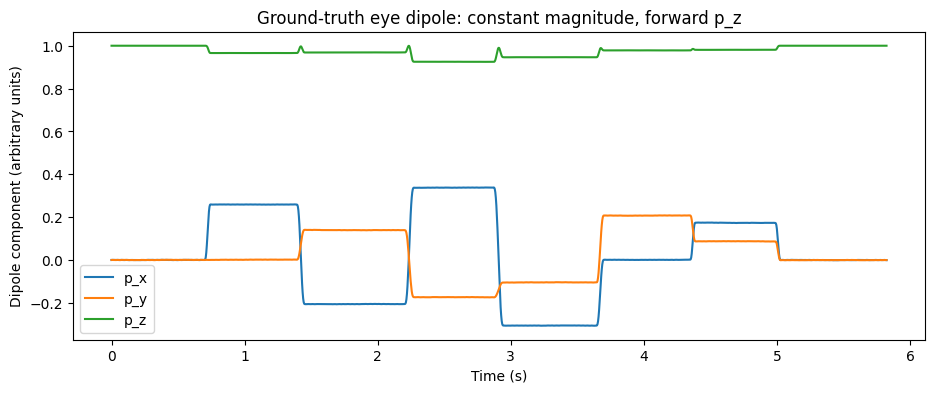

Dipole magnitude range: 0.9999999999999998 to 1.0
Minimum p_z: 0.9247380684689058


In [7]:
plt.figure(figsize=(11, 4))
plt.plot(time, true_dipole[:, 0], label="p_x")
plt.plot(time, true_dipole[:, 1], label="p_y")
plt.plot(time, true_dipole[:, 2], label="p_z")
plt.xlabel("Time (s)")
plt.ylabel("Dipole component (arbitrary units)")
plt.title("Ground-truth eye dipole: constant magnitude, forward p_z")
plt.legend()
plt.show()

print(
    "Dipole magnitude range:",
    np.linalg.norm(true_dipole, axis=1).min(),
    "to",
    np.linalg.norm(true_dipole, axis=1).max(),
)
print("Minimum p_z:", true_dipole[:, 2].min())

## Generate EOG measurements

The synthetic recording is generated with the **finite near-field model**. We then add two simple nuisance terms:

- independent white measurement noise;
- a small slow baseline drift in each bipolar channel.

The drift is deliberately modest. A production preprocessing pipeline would usually high-pass, detrend, or explicitly model this baseline component.

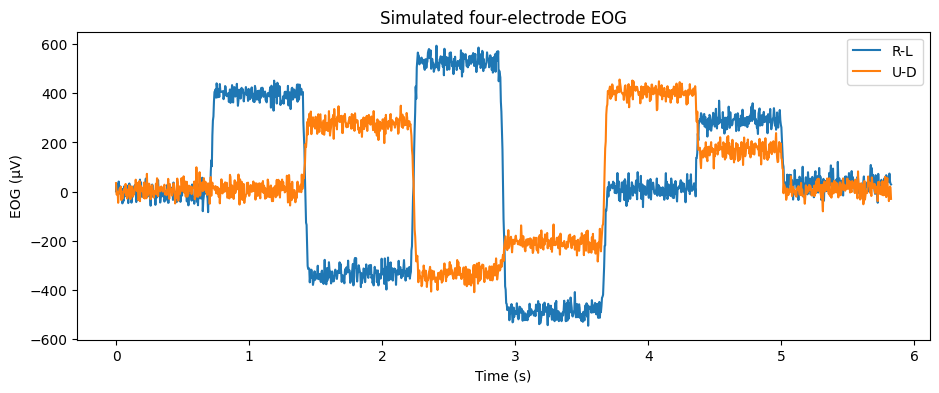

In [8]:
def add_eog_noise(clean_eog, fs, white_noise_std=25e-6, drift_std=12e-6, random_state=0):
    """Add white electrode noise and slow channel drift to simulated EOG.

    Parameters
    ----------
    clean_eog : numpy.ndarray, shape (n_samples, n_channels)
        Noise-free EOG generated by a forward model.
    fs : float
        Sampling rate in Hz.
    white_noise_std : float, default=25e-6
        Standard deviation of independent sample noise, in volts.
    drift_std : float, default=12e-6
        Approximate scale of slow baseline drift, in volts.
    random_state : int, default=0
        Random seed.

    Returns
    -------
    noisy_eog : numpy.ndarray, shape (n_samples, n_channels)
        Simulated measured EOG.
    """
    local_rng = np.random.default_rng(random_state)
    clean_eog = np.asarray(clean_eog, dtype=float)
    n_samples, n_channels = clean_eog.shape

    white_noise = local_rng.normal(
        scale=white_noise_std,
        size=clean_eog.shape,
    )

    # Build slow drift from a highly correlated process. Each channel drifts
    # independently so the example does not rely on perfectly shared baselines.
    drift = np.zeros_like(clean_eog)
    innovation_std = drift_std * 0.06
    for k in range(1, n_samples):
        drift[k] = 0.998 * drift[k - 1] + local_rng.normal(
            scale=innovation_std,
            size=n_channels,
        )

    return clean_eog + white_noise + drift


clean_eog = near_model.forward(true_dipole)
measured_eog = add_eog_noise(
    clean_eog,
    fs=fs,
    white_noise_std=25e-6,
    drift_std=12e-6,
    random_state=11,
)

plt.figure(figsize=(11, 4))
plt.plot(time, measured_eog[:, 0] * 1e6, label="R-L")
plt.plot(time, measured_eog[:, 1] * 1e6, label="U-D")
plt.xlabel("Time (s)")
plt.ylabel("EOG (µV)")
plt.title("Simulated four-electrode EOG")
plt.legend()
plt.show()

## A constrained 2-D dipole estimator

The estimator below is intentionally explicit.

The hidden state is

\[
\mathbf x_t = [p_x(t),p_y(t)]^T.
\]

Before evaluating either physical forward model, it is lifted onto the forward hemisphere of a sphere:

\[
\mathbf p_t =
\begin{bmatrix}
p_x(t)\\
p_y(t)\\
+\sqrt{p_0^2-p_x(t)^2-p_y(t)^2}
\end{bmatrix}.
\]

The temporal model is a 2-D random walk. Because this spherical reconstruction makes even the far-field observation nonlinear in the two state variables, the same small extended Kalman filter can be used for **both** physical models.

This is preferable to running a 3-D filter with a rank-deficient two-channel observation matrix and hoping the prior invents the missing dimension.

In [9]:
from dataclasses import dataclass


def project_xy_to_valid_disk(p_xy, magnitude):
    """Keep a 2-D state inside the sphere where a real positive p_z exists."""
    p_xy = np.asarray(p_xy, dtype=float).copy()
    radius = np.linalg.norm(p_xy)
    maximum_radius = 0.999 * float(magnitude)

    if radius > maximum_radius:
        p_xy *= maximum_radius / radius

    return p_xy


def xy_to_forward_dipole(p_xy, magnitude=1.0):
    """Lift observable (p_x, p_y) onto a fixed-magnitude forward 3-D dipole.

    Parameters
    ----------
    p_xy : numpy.ndarray, shape (2,)
        Horizontal and vertical dipole components estimated from EOG.
    magnitude : float, default=1.0
        Assumed constant norm of the full 3-D dipole.

    Returns
    -------
    dipole : numpy.ndarray, shape (3,)
        Full dipole ``[p_x, p_y, p_z]`` with positive ``p_z``.
    """
    p_xy = project_xy_to_valid_disk(p_xy, magnitude)
    remaining_squared = magnitude**2 - np.dot(p_xy, p_xy)
    p_z = np.sqrt(max(remaining_squared, 0.0))
    return np.array([p_xy[0], p_xy[1], p_z])


def observation_jacobian_2d(forward_model, p_xy, magnitude, step=1e-5):
    """Numerically differentiate EOG with respect to p_x and p_y.

    The finite-difference implementation is slower than an analytic Jacobian,
    but it is short, transparent, and works identically for the near- and
    far-field models in this demonstration.
    """
    p_xy = np.asarray(p_xy, dtype=float)
    n_channels = len(forward_model.channel_names)
    jacobian = np.zeros((n_channels, 2))

    for dimension in range(2):
        delta = np.zeros(2)
        delta[dimension] = step

        p_plus = xy_to_forward_dipole(p_xy + delta, magnitude)
        p_minus = xy_to_forward_dipole(p_xy - delta, magnitude)

        y_plus = forward_model.forward(p_plus)
        y_minus = forward_model.forward(p_minus)
        jacobian[:, dimension] = (y_plus - y_minus) / (2.0 * step)

    return jacobian


@dataclass
class ConstrainedDipoleEstimate:
    """Container for a constrained 2-D filter and smoother result."""

    filtered_xy: np.ndarray
    smoothed_xy: np.ndarray
    filtered_covariance: np.ndarray
    smoothed_covariance: np.ndarray
    dipole_magnitude: float

    @property
    def dipole(self):
        """Return the smoothed states reconstructed as full 3-D dipoles."""
        return np.asarray([
            xy_to_forward_dipole(p_xy, self.dipole_magnitude)
            for p_xy in self.smoothed_xy
        ])


class ConstrainedDipoleSmoother:
    """Estimate a fixed-magnitude eye dipole from two-channel EOG.

    Parameters
    ----------
    forward_model : EyePole
        Physics model used to predict EOG from a full three-dimensional dipole.
        It may be either the finite near-field model or the far-field model.
    dipole_magnitude : float, default=1.0
        Assumed constant norm of the eye dipole. Only p_x and p_y are estimated;
        p_z is reconstructed as the positive square root required by this norm.
    process_std : float, default=0.005
        Standard deviation of the random-walk change in p_x and p_y per sample.
        Larger values follow saccades more rapidly but pass more measurement
        noise. The covariance used by the filter is ``process_std**2 * I``.
    measurement_std : float, default=25e-6
        Standard deviation of EOG measurement noise in volts. The example uses
        the same value for both bipolar channels.
    initial_std : float, default=0.15
        Prior standard deviation for p_x and p_y at the first sample.
    """

    def __init__(
        self,
        forward_model,
        dipole_magnitude=1.0,
        process_std=0.01,
        measurement_std=25e-6,
        initial_std=0.15,
    ):
        self.forward_model = forward_model
        self.dipole_magnitude = float(dipole_magnitude)
        self.process_std = float(process_std)
        self.measurement_std = float(measurement_std)
        self.initial_std = float(initial_std)

    def _observe_xy(self, p_xy):
        """Predict EOG after reconstructing the positive-z 3-D dipole."""
        dipole = xy_to_forward_dipole(p_xy, self.dipole_magnitude)
        return self.forward_model.forward(dipole)

    def fit(self, eog, initial_xy=None):
        """Run a 2-D extended Kalman filter followed by an RTS smoother.

        Parameters
        ----------
        eog : numpy.ndarray, shape (n_samples, n_channels)
            Measured bipolar EOG channels in the order expected by the forward
            model.
        initial_xy : numpy.ndarray or None, shape (2,), default=None
            Optional starting values for p_x and p_y. ``None`` starts at
            straight-ahead gaze, i.e. p_x = p_y = 0 and p_z > 0.

        Returns
        -------
        result : ConstrainedDipoleEstimate
            Filtered and smoothed two-dimensional states plus reconstructed
            three-dimensional dipoles.
        """
        eog = np.asarray(eog, dtype=float)
        if eog.ndim != 2:
            raise ValueError("eog must have shape (n_samples, n_channels)")
        if eog.shape[1] != len(self.forward_model.channel_names):
            raise ValueError("eog channel count does not match the forward model")

        n_samples = len(eog)
        state_dimension = 2
        identity = np.eye(state_dimension)

        process_covariance = np.eye(2) * self.process_std**2
        measurement_covariance = (
            np.eye(eog.shape[1]) * self.measurement_std**2
        )

        if initial_xy is None:
            state = np.zeros(2)
        else:
            state = project_xy_to_valid_disk(
                np.asarray(initial_xy, dtype=float),
                self.dipole_magnitude,
            )

        covariance = np.eye(2) * self.initial_std**2

        filtered = np.zeros((n_samples, 2))
        filtered_covariance = np.zeros((n_samples, 2, 2))
        predicted = np.zeros((n_samples, 2))
        predicted_covariance = np.zeros((n_samples, 2, 2))

        for k in range(n_samples):
            # Random-walk prediction: before seeing the next EOG sample, the
            # best guess is that the eye remained near its previous direction.
            state_pred = state.copy()
            covariance_pred = covariance + process_covariance

            # The observation is nonlinear because p_z depends on p_x and p_y,
            # and the near-field model is nonlinear as well. We therefore use
            # the local slope of EOG with respect to the two estimated states.
            C_local = observation_jacobian_2d(
                self.forward_model,
                state_pred,
                self.dipole_magnitude,
            )
            eog_pred = self._observe_xy(state_pred)
            innovation = eog[k] - eog_pred
            innovation_covariance = (
                C_local @ covariance_pred @ C_local.T
                + measurement_covariance
            )

            kalman_gain = np.linalg.solve(
                innovation_covariance.T,
                (covariance_pred @ C_local.T).T,
            ).T

            state = state_pred + kalman_gain @ innovation
            state = project_xy_to_valid_disk(state, self.dipole_magnitude)

            # Joseph form keeps the covariance symmetric and positive more
            # reliably than the shorter algebraic update.
            residual_map = identity - kalman_gain @ C_local
            covariance = (
                residual_map @ covariance_pred @ residual_map.T
                + kalman_gain @ measurement_covariance @ kalman_gain.T
            )

            predicted[k] = state_pred
            predicted_covariance[k] = covariance_pred
            filtered[k] = state
            filtered_covariance[k] = covariance

        # Rauch-Tung-Striebel backward pass. Because the state dynamics are an
        # identity random walk, the transition matrix does not clutter the code.
        smoothed = filtered.copy()
        smoothed_covariance = filtered_covariance.copy()

        for k in range(n_samples - 2, -1, -1):
            smoother_gain = np.linalg.solve(
                predicted_covariance[k + 1].T,
                filtered_covariance[k].T,
            ).T

            smoothed[k] = filtered[k] + smoother_gain @ (
                smoothed[k + 1] - predicted[k + 1]
            )
            smoothed[k] = project_xy_to_valid_disk(
                smoothed[k],
                self.dipole_magnitude,
            )

            smoothed_covariance[k] = (
                filtered_covariance[k]
                + smoother_gain
                @ (smoothed_covariance[k + 1] - predicted_covariance[k + 1])
                @ smoother_gain.T
            )

        return ConstrainedDipoleEstimate(
            filtered_xy=filtered,
            smoothed_xy=smoothed,
            filtered_covariance=filtered_covariance,
            smoothed_covariance=smoothed_covariance,
            dipole_magnitude=self.dipole_magnitude,
        )

In [10]:
# A single process-noise setting is used for both estimators so that the
# comparison is about the physical observation model, not different tuning.
near_estimator = ConstrainedDipoleSmoother(
    forward_model=near_model,
    dipole_magnitude=dipole_magnitude,
    process_std=np.sqrt(3e-5),
    measurement_std=25e-6,
)

far_estimator = ConstrainedDipoleSmoother(
    forward_model=far_model,
    dipole_magnitude=dipole_magnitude,
    process_std=np.sqrt(3e-5),
    measurement_std=25e-6,
)

near_result = near_estimator.fit(measured_eog)
far_result = far_estimator.fit(measured_eog)

near_dipole = near_result.dipole
far_dipole = far_result.dipole

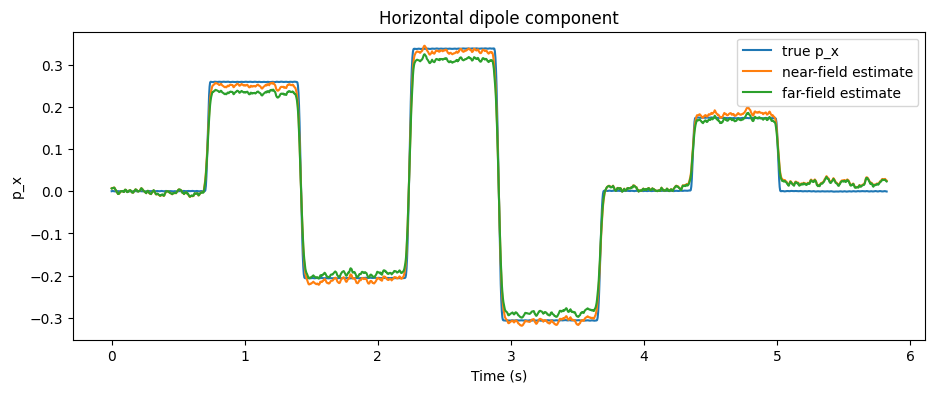

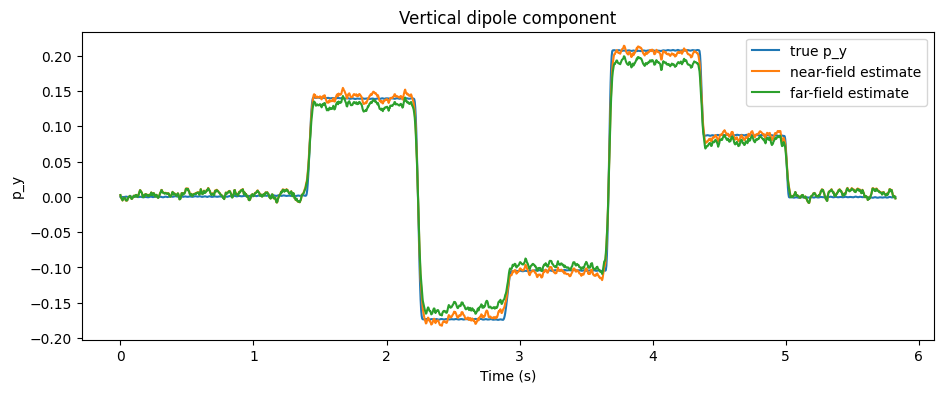

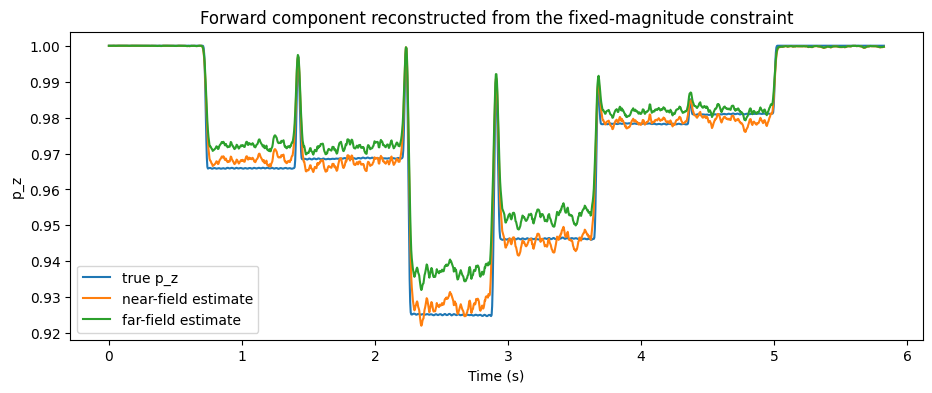

In [11]:
plt.figure(figsize=(11, 4))
plt.plot(time, true_dipole[:, 0], label="true p_x")
plt.plot(time, near_dipole[:, 0], label="near-field estimate")
plt.plot(time, far_dipole[:, 0], label="far-field estimate")
plt.xlabel("Time (s)")
plt.ylabel("p_x")
plt.title("Horizontal dipole component")
plt.legend()
plt.show()

plt.figure(figsize=(11, 4))
plt.plot(time, true_dipole[:, 1], label="true p_y")
plt.plot(time, near_dipole[:, 1], label="near-field estimate")
plt.plot(time, far_dipole[:, 1], label="far-field estimate")
plt.xlabel("Time (s)")
plt.ylabel("p_y")
plt.title("Vertical dipole component")
plt.legend()
plt.show()

plt.figure(figsize=(11, 4))
plt.plot(time, true_dipole[:, 2], label="true p_z")
plt.plot(time, near_dipole[:, 2], label="near-field estimate")
plt.plot(time, far_dipole[:, 2], label="far-field estimate")
plt.xlabel("Time (s)")
plt.ylabel("p_z")
plt.title("Forward component reconstructed from the fixed-magnitude constraint")
plt.legend()
plt.show()

In [12]:
def dipole_rmse(estimate, truth):
    """Root-mean-square Euclidean error of a dipole trajectory."""
    return np.sqrt(np.mean(np.sum((estimate - truth) ** 2, axis=1)))


print("Near-field dipole RMSE:", dipole_rmse(near_dipole, true_dipole))
print("Far-field dipole RMSE: ", dipole_rmse(far_dipole, true_dipole))

Near-field dipole RMSE: 0.015804786070933684
Far-field dipole RMSE:  0.023714909511767975


## Convert the estimated dipole to gaze

Because the simulator explicitly defines how gaze direction rotates the dipole, it has an exact geometric inverse. That is useful for checking the simulation.

In a real experiment, however, the relationship between inferred dipole coordinates and actual visual angle will not be known perfectly. Electrode placement, head geometry, gain, and the physical dipole model can all introduce systematic distortions.

A practical solution is a **gaze calibration transfer function**: ask the subject to look at known targets, estimate their eye dipole at those targets, then regress target angle on the estimated dipole coordinates.

The next section demonstrates both approaches.

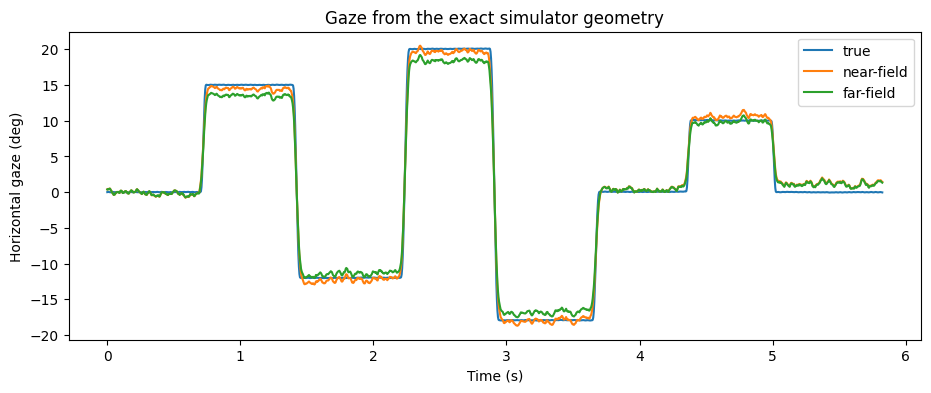

In [13]:
# First, use the exact analytic inverse implied by the simulator.
near_angles_analytic = dipole_to_gaze_angles(near_dipole)
far_angles_analytic = dipole_to_gaze_angles(far_dipole)

plt.figure(figsize=(11, 4))
plt.plot(time, horizontal_true_deg, label="true")
plt.plot(time, near_angles_analytic[:, 0], label="near-field")
plt.plot(time, far_angles_analytic[:, 0], label="far-field")
plt.xlabel("Time (s)")
plt.ylabel("Horizontal gaze (deg)")
plt.title("Gaze from the exact simulator geometry")
plt.legend()
plt.show()

### Build a calibration transfer function from simulated targets

We simulate a small grid of known gaze targets. At each target we generate EOG with the near-field generative model, estimate the 2-D dipole, and retain the settled estimate. A low-order polynomial is then fit from estimated \((p_x,p_y)\) to horizontal and vertical gaze angle.

This step is deliberately separated from the physical EOG model:

\[
\text{EOG} \rightarrow \widehat{\mathbf p}_{xy}
\rightarrow \text{calibration transfer}
\rightarrow \widehat{\text{gaze angle}}.
\]

In real data, the target angles would come from the visual calibration task rather than the simulator.

In [14]:
def polynomial_features_2d(p_xy):
    """Readable third-order polynomial features for a 2-D calibration map."""
    p_xy = np.asarray(p_xy, dtype=float)
    x = p_xy[:, 0]
    y = p_xy[:, 1]

    return np.column_stack([
        np.ones(len(p_xy)),
        x,
        y,
        x**2,
        x * y,
        y**2,
        x**3,
        x**2 * y,
        x * y**2,
        y**3,
    ])


class GazeTransferFunction:
    """Polynomial map from estimated 2-D dipole coordinates to gaze angle.

    The class is intentionally small. It uses ordinary least squares so the
    fitted transfer can be inspected directly and does not require an external
    machine-learning package.
    """

    def __init__(self):
        self.coefficients_ = None

    def fit(self, dipole_xy, gaze_angles_deg):
        """Fit the calibration map from dipole coordinates to known targets.

        Parameters
        ----------
        dipole_xy : numpy.ndarray, shape (n_targets, 2)
            Estimated p_x and p_y at each calibration target.
        gaze_angles_deg : numpy.ndarray, shape (n_targets, 2)
            Known horizontal and vertical target angles in degrees.
        """
        design = polynomial_features_2d(dipole_xy)
        gaze_angles_deg = np.asarray(gaze_angles_deg, dtype=float)
        self.coefficients_, *_ = np.linalg.lstsq(
            design,
            gaze_angles_deg,
            rcond=None,
        )
        return self

    def transform(self, dipole_xy):
        """Convert estimated p_x/p_y values into gaze angles in degrees."""
        if self.coefficients_ is None:
            raise RuntimeError("fit the transfer function before using it")
        design = polynomial_features_2d(dipole_xy)
        return design @ self.coefficients_

In [15]:
def build_simulated_calibration(estimator, generator, random_state=0):
    """Simulate a gaze-target calibration and return settled dipole estimates."""
    local_rng = np.random.default_rng(random_state)

    horizontal_targets = [-20.0, -10.0, 0.0, 10.0, 20.0]
    vertical_targets = [-12.0, -6.0, 0.0, 6.0, 12.0]

    estimated_xy = []
    target_angles = []

    for horizontal in horizontal_targets:
        for vertical in vertical_targets:
            # Hold each calibration target long enough for the random-walk
            # filter to settle. We average only the latter half of the trial.
            n_samples = 80
            dipoles = gaze_angles_to_dipole(
                np.full(n_samples, horizontal),
                np.full(n_samples, vertical),
                magnitude=dipole_magnitude,
            )
            clean = generator.forward(dipoles)
            noisy = clean + local_rng.normal(
                scale=25e-6,
                size=clean.shape,
            )

            result = estimator.fit(noisy)
            settled_xy = result.smoothed_xy[n_samples // 2 :].mean(axis=0)

            estimated_xy.append(settled_xy)
            target_angles.append([horizontal, vertical])

    return np.asarray(estimated_xy), np.asarray(target_angles)


near_calibration_xy, calibration_angles = build_simulated_calibration(
    near_estimator,
    near_model,
    random_state=21,
)
far_calibration_xy, _ = build_simulated_calibration(
    far_estimator,
    near_model,  # data are still generated from the finite near-field physics
    random_state=21,
)

near_transfer = GazeTransferFunction().fit(
    near_calibration_xy,
    calibration_angles,
)
far_transfer = GazeTransferFunction().fit(
    far_calibration_xy,
    calibration_angles,
)

near_angles_calibrated = near_transfer.transform(near_result.smoothed_xy)
far_angles_calibrated = far_transfer.transform(far_result.smoothed_xy)

In [16]:
def angle_rmse(estimate_deg, horizontal_truth_deg, vertical_truth_deg):
    truth = np.column_stack([horizontal_truth_deg, vertical_truth_deg])
    return np.sqrt(np.mean((estimate_deg - truth) ** 2, axis=0))


near_rmse = angle_rmse(
    near_angles_calibrated,
    horizontal_true_deg,
    vertical_true_deg,
)
far_rmse = angle_rmse(
    far_angles_calibrated,
    horizontal_true_deg,
    vertical_true_deg,
)

print(
    "Near-field calibrated gaze RMSE: "
    f"horizontal={near_rmse[0]:.3f}°, vertical={near_rmse[1]:.3f}°"
)
print(
    "Far-field calibrated gaze RMSE:  "
    f"horizontal={far_rmse[0]:.3f}°, vertical={far_rmse[1]:.3f}°"
)

Near-field calibrated gaze RMSE: horizontal=0.809°, vertical=0.375°
Far-field calibrated gaze RMSE:  horizontal=0.787°, vertical=0.372°


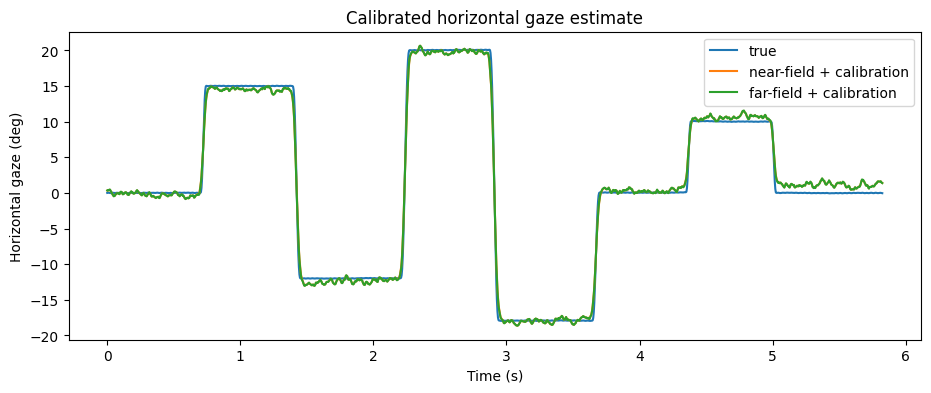

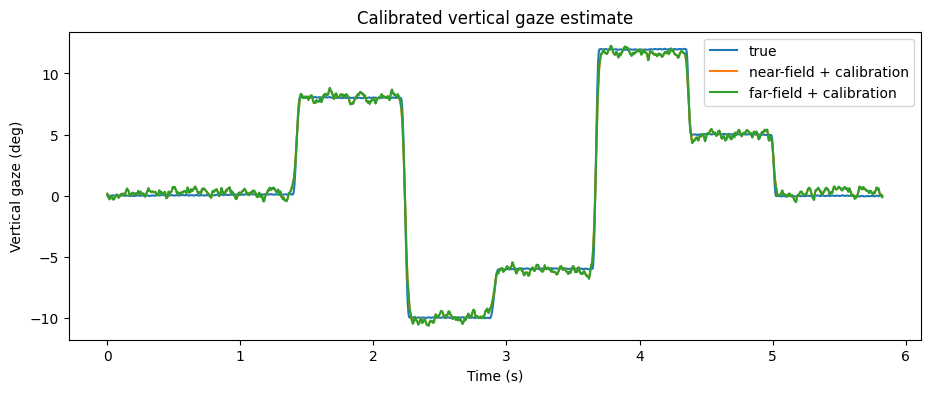

In [17]:
plt.figure(figsize=(11, 4))
plt.plot(time, horizontal_true_deg, label="true")
plt.plot(time, near_angles_calibrated[:, 0], label="near-field + calibration")
plt.plot(time, far_angles_calibrated[:, 0], label="far-field + calibration")
plt.xlabel("Time (s)")
plt.ylabel("Horizontal gaze (deg)")
plt.title("Calibrated horizontal gaze estimate")
plt.legend()
plt.show()

plt.figure(figsize=(11, 4))
plt.plot(time, vertical_true_deg, label="true")
plt.plot(time, near_angles_calibrated[:, 1], label="near-field + calibration")
plt.plot(time, far_angles_calibrated[:, 1], label="far-field + calibration")
plt.xlabel("Time (s)")
plt.ylabel("Vertical gaze (deg)")
plt.title("Calibrated vertical gaze estimate")
plt.legend()
plt.show()

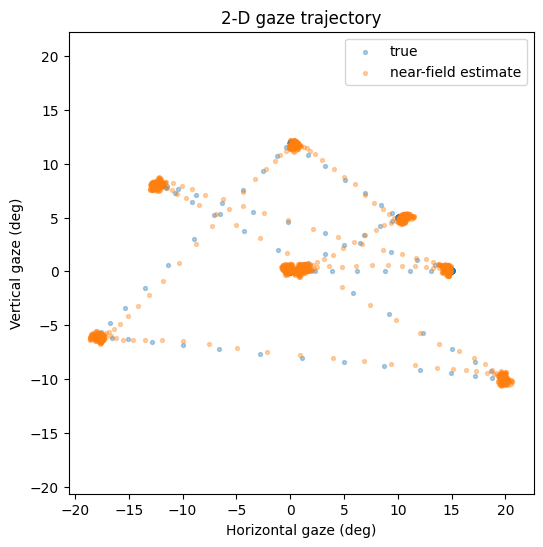

In [18]:
plt.figure(figsize=(6, 6))
plt.scatter(horizontal_true_deg, vertical_true_deg, s=8, alpha=0.35, label="true")
plt.scatter(
    near_angles_calibrated[:, 0],
    near_angles_calibrated[:, 1],
    s=8,
    alpha=0.35,
    label="near-field estimate",
)
plt.xlabel("Horizontal gaze (deg)")
plt.ylabel("Vertical gaze (deg)")
plt.title("2-D gaze trajectory")
plt.legend()
plt.axis("equal")
plt.show()

## What this notebook is showing

The four-electrode montage does **not** identify an arbitrary three-component dipole. The estimator becomes well posed only after adding a meaningful physical constraint: approximately constant dipole magnitude and a forward-facing positive \(p_z\).

That gives a useful hierarchy:

1. **Latent state:** estimate only \((p_x,p_y)\).
2. **Spherical constraint:** reconstruct positive \(p_z\).
3. **Physics:** map the resulting 3-D dipole to EOG with either the finite near-field or point-dipole far-field model.
4. **Temporal inference:** use the EOG sequence to smooth the two observable degrees of freedom.
5. **Gaze calibration:** map estimated dipole coordinates to visual angle using known targets.

The calibrated far-field model can perform surprisingly well even when the data were generated by the finite near-field model, because the gaze transfer function can absorb some systematic geometric distortion. That does **not** mean the two physical models are equivalent: changing electrode distance, pole separation, or gaze range can make their differences larger.

### Natural next package change

The main `EyePole.estimate()` method currently estimates an unconstrained 3-D state. For a U/D/L/R-only workflow, the constrained two-state estimator in this notebook is a better default. A clean next step would be to move this implementation into the package as something like

```python
model.estimate(eog, dipole_magnitude=1.0, constrain_to_forward_sphere=True)
```

or to make the constrained formulation the standard behavior whenever the montage supplies only two independent EOG channels.